In [2]:
from google.colab import drive
drive.mount('/content/drive')

!pip install torch_geometric rdkit

!cp /content/drive/MyDrive/graph_vae_project.zip /content/

!unzip -q /content/graph_vae_project.zip -d /content/



Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 27.9 MB/s eta 0:00:00


In [5]:
import os

os.chdir('/content/src')

!python train_model_gcn1.py

!cp /content/src/model1_weights.pth /content/drive/MyDrive/

using device: cuda
loading data..
training on 15888 graphs...
Epoch 001/025 | Train Loss: 0.5539 (Recon: 0.5534, KL: 0.5367) | Val Loss: 0.0692
Epoch 005/025 | Train Loss: 0.0691 (Recon: 0.0684, KL: 0.7045) | Val Loss: 0.0683
Epoch 010/025 | Train Loss: 0.0651 (Recon: 0.0643, KL: 0.7656) | Val Loss: 0.0641
Epoch 015/025 | Train Loss: 0.0632 (Recon: 0.0624, KL: 0.8220) | Val Loss: 0.0625
Epoch 020/025 | Train Loss: 0.0621 (Recon: 0.0613, KL: 0.7931) | Val Loss: 0.0615
Epoch 025/025 | Train Loss: 0.0614 (Recon: 0.0607, KL: 0.7223) | Val Loss: 0.0613
Figure(1000x500)


using device: cuda
Sampling 1000 random vectors from latent space...


  0%|          | 0/1000 [00:00<?, ?it/s][15:20:03] Explicit valence for atom # 1 C, 6, is greater than permitted
[15:20:03] Explicit valence for atom # 1 C, 8, is greater than permitted
[15:20:03] Explicit valence for atom # 1 C, 5, is greater than permitted
[15:20:03] Explicit valence for atom # 4 C, 5, is greater than permitted
[15:20:03] Explicit valence for atom # 0 C, 5, is greater than permitted
[15:20:03] Explicit valence for atom # 1 C, 11, is greater than permitted
[15:20:03] Explicit valence for atom # 5 C, 5, is greater than permitted
[15:20:03] Explicit valence for atom # 19 C, 6, is greater than permitted
[15:20:03] Explicit valence for atom # 1 C, 8, is greater than permitted
  5%|▌         | 54/1000 [00:00<00:01, 534.62it/s][15:20:03] Explicit valence for atom # 1 C, 5, is greater than permitted
[15:20:03] Explicit valence for atom # 1 C, 5, is greater than permitted
[15:20:03] Explicit valence for atom # 1 C, 7, is greater than permitted
[15:20:03] Explicit valence for 


--- VUN Analysis ---
Validity (Poprawność):  66.20% (662/1000)
Uniqueness (Unikalność): 74.77% (495/662)
Novelty (Nowość):       99.60% (493/495)
Unique smiles generated: {'CCCCCCCCCCCCCC', 'C.CCCCCCCCCCCCCCCCCCCCCCCCCCC', 'C.C.CC(C)C.CC1CC2(C3C2C3(C)C)C12CCC2', 'C.C.CCC.CCCCCC.CCCCCCCCCCCCCCC', 'CC12CCC1CC1CC12', 'C.CCC1CC1C.CCCC(C)C', 'CC.CCCCCCCCCCCCCCCCCCCCCCCCCCC', 'C.CC(C)(C)C.CC1CC1', 'CCCCCCCCCCCCCCCCCCCCCCCCCCCCCC1CC1C', 'CC.CCCCCCCCCCCCCCCCC', 'CC.CCCCCCCCCCCCCCCCCCCCC', 'CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC', 'C.C.CBr.CC.CC1(I)CC1CCC1CC12CI2O.CN', 'C.C.CC(C)(C)CC1(C)C2C(C3CC3)C21.CCC1CCC12CC21CCC1C1CC1', 'C.C.CCCCCC(C)C.CCCCCCC', 'CC1C2CCC1C2C', 'CCCCCCCCCCC', 'C.CCCCCCCCCCCC(C)CCCCCCC(C)CCCCCC', 'CC.CCCCCCCCCCC', 'CC1(C)CC1.CCCC', 'CCCC(C)(C)C.CCCCCCCCCCCCCCCCCCCCC1CC1CCCC', 'C.C.CCCC(C)(C)C.CCCCCCCC.CCCCCCCCCCCC', 'CCCCCCCCCC', 'CCCC(C)(C)C.CCCCCCCCCCCCCCCCCC1CC1C1CC1CCC', 'CC.CCCCCCCCCCCCC', 'C.CCCCCCCC', 'CC.CCCCCCCCC1CCCCC1C', 'CCCC.CCCCCCCCCCCCCCCCCCCCCCCC', 'C.C.C.C.CC

100%|██████████| 16/16 [00:01<00:00, 12.24it/s]


Running t-SNE dimensionality reduction...
Latent space visualization saved as 'latent_space_analysis.png'


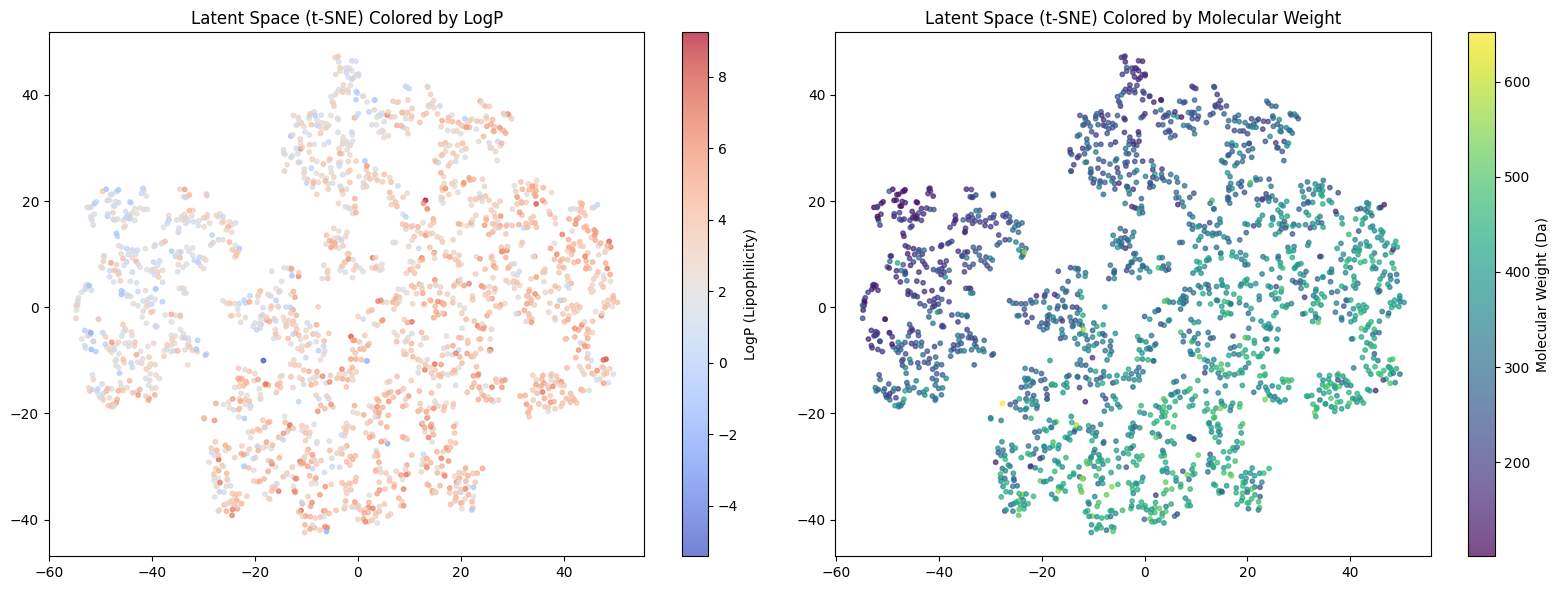

In [6]:
import torch
import pandas as pd
from torch_geometric.loader import DataLoader
import os

os.chdir('/content/src')
from train_model_gcn1 import GraphVAE
from evaluate import GraphVAEEvaluator

SUPPORTED_ATOMS = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]
NUM_ATOM_TYPES = len(SUPPORTED_ATOMS)
NODE_FEATURES = 30
HIDDEN_DIM = 64
LATENT_DIM = 128
MAX_NODES = 37

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GraphVAE(NODE_FEATURES, HIDDEN_DIM, LATENT_DIM, MAX_NODES, NUM_ATOM_TYPES)
model.load_state_dict(torch.load('model1_weights.pth', map_location=device, weights_only=True))
model = model.to(device)
model.eval()

csv_path = '/content/drive/MyDrive/smiles_selfies_full.csv'
df = pd.read_csv(csv_path)
train_smiles_list = df['smiles'].tolist()

test_dataset = torch.load('../data/subset/test.pt', weights_only=False)
test_dataset = [g for g in test_dataset if g.num_nodes <= MAX_NODES]
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

evaluator = GraphVAEEvaluator(
    model=model,
    device=device,
    max_nodes=MAX_NODES,
    train_smiles_list=train_smiles_list
)

validity, uniqueness, novelty = evaluator.evaluate_vun(num_samples=1000)

evaluator.visualize_latent_space(test_loader)